# Laboratorio 8 – Deep Learning
## Task 3: Embeddings contextuales (BERT multilingüe) vs. estáticos (Word2Vec)

Se usa `bert-base-multilingual-cased` (HuggingFace `transformers`) para extraer el embedding **contextual** de la última capa de una palabra ambigua en distintos contextos, y se compara con el vector **estático** de un Word2Vec preentrenado de `gensim`.

Idea central: en un Transformer la representación de un token en la capa $L$ es
$$h_i^{(L)} = f\big(x_1,\dots,x_n\big)_i,$$
es decir, depende de **toda** la oración vía self-attention $\text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$ (bidireccional en BERT, sin máscara causal). En Word2Vec, en cambio, cada palabra tiene **un único** vector $v_w = E[w]$ (una fila de la matriz de embeddings), independiente del contexto.

In [1]:
import itertools, re
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
from sklearn.decomposition import PCA

torch.manual_seed(42)
print('PyTorch', torch.__version__)

PyTorch 2.13.0+cpu


## Task 3.1 – Extracción de embeddings contextuales

In [2]:
# (oración, palabra objetivo, etiqueta del significado)
DATA = [
    ('El banco central anunció una subida de tasas de interés.',         'banco', 'banco (finanzas)'),
    ('Me senté en el banco del parque a leer el periódico.',              'banco', 'banco (asiento)'),
    ('El banco de peces se movió velozmente ante el tiburón.',            'banco', 'banco (peces)'),
    ('El equipo levantó la copa del torneo ante miles de aficionados.',   'copa',  'copa (trofeo)'),
    ('Sirvió una copa de vino tinto para acompañar la cena.',             'copa',  'copa (vino)'),
    ('El velero desplegó su vela para aprovechar el viento.',             'vela',  'vela (náutica)'),
    ('Encendió una vela para iluminar el cuarto durante el apagón.',      'vela',  'vela (cera)'),
]

MODEL_NAME = 'bert-base-multilingual-cased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert = AutoModel.from_pretrained(MODEL_NAME).eval()
print('Capas:', bert.config.num_hidden_layers, '| d_model:', bert.config.hidden_size)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Capas: 12 | d_model: 768


In [3]:
@torch.no_grad()
def contextual_embedding(sentence, word):
    # 1) Ubicar la palabra objetivo (como palabra completa) por caracteres en la oración.
    m = re.search(rf'\b{re.escape(word)}\b', sentence)
    start, end = m.span()
    # 2) Tokenizar con offsets para saber qué sub-tokens WordPiece cubren esos caracteres.
    enc = tokenizer(sentence, return_tensors='pt', return_offsets_mapping=True)
    offsets = enc.pop('offset_mapping')[0]
    idx = [i for i, (s, e) in enumerate(offsets.tolist()) if e > s and s >= start and e <= end]
    # 3) Forward: last_hidden_state = h^(L) con L = 12, forma (1, n_tokens, 768).
    #    Se toma el vector del token de la palabra objetivo (NO el [CLS], posición 0).
    h = bert(**enc).last_hidden_state[0]
    tokens = tokenizer.convert_ids_to_tokens(enc['input_ids'][0][idx])
    # Si WordPiece partiera la palabra en varios sub-tokens, se promedian: h_w = (1/|S|) sum_{i in S} h_i
    return h[idx].mean(0), tokens

embs, rows = [], []
for sent, word, sense in DATA:
    v, toks = contextual_embedding(sent, word)
    embs.append(v)
    rows.append({'palabra': word, 'significado': sense, 'sub-tokens': toks, 'dim': tuple(v.shape)[0], 'oración': sent})
E = torch.stack(embs).numpy()
assert E.shape == (len(DATA), 768)
pd.set_option('display.max_colwidth', 80)
pd.DataFrame(rows)

,palabra,significado,sub-tokens,dim,oración
0,banco,banco (finanzas),[banco],768,El banco central anunció una subida de tasas de interés.
1,banco,banco (asiento),[banco],768,Me senté en el banco del parque a leer el periódico.
2,banco,banco (peces),[banco],768,El banco de peces se movió velozmente ante el tiburón.
3,copa,copa (trofeo),[copa],768,El equipo levantó la copa del torneo ante miles de aficionados.
4,copa,copa (vino),[copa],768,Sirvió una copa de vino tinto para acompañar la cena.
5,vela,vela (náutica),[vela],768,El velero desplegó su vela para aprovechar el viento.
6,vela,vela (cera),[vela],768,Encendió una vela para iluminar el cuarto durante el apagón.


## Task 3.2 a – Similitud coseno entre contextos (BERT)

$$\text{sim}(\mathbf u,\mathbf v)=\frac{\mathbf u^\top\mathbf v}{\lVert\mathbf u\rVert\,\lVert\mathbf v\rVert}$$

In [4]:
def cos_sim(u, v):
    # sim(u, v) = u^T v / (||u|| * ||v||)
    return float(u @ v / (np.linalg.norm(u) * np.linalg.norm(v)))

def pair_table(get_vec):
    # Todos los pares de instancias de la MISMA palabra objetivo en contextos distintos
    out = []
    for i, j in itertools.combinations(range(len(DATA)), 2):
        if DATA[i][1] == DATA[j][1]:
            out.append({'palabra': DATA[i][1], 'contexto 1': DATA[i][2], 'contexto 2': DATA[j][2],
                        'sim': cos_sim(get_vec(i), get_vec(j))})
    return pd.DataFrame(out)

bert_tab = pair_table(lambda i: E[i]).rename(columns={'sim': 'sim BERT'})
bert_tab.round(4)

,palabra,contexto 1,contexto 2,sim BERT
0,banco,banco (finanzas),banco (asiento),0.5753
1,banco,banco (finanzas),banco (peces),0.6603
2,banco,banco (asiento),banco (peces),0.6496
3,copa,copa (trofeo),copa (vino),0.5667
4,vela,vela (náutica),vela (cera),0.7999


Misma palabra, distinto contexto: media = 0.6504
Palabras distintas:               media = 0.3912  (min 0.3230, max 0.4936)


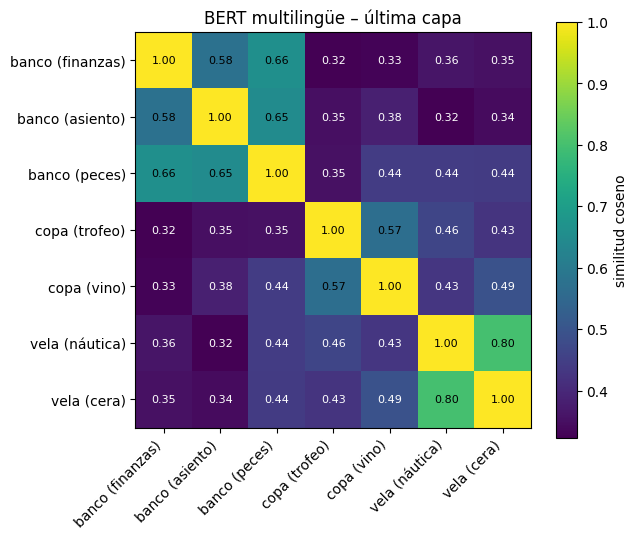

In [5]:
# Referencia: similitud entre palabras DISTINTAS (para tener una escala de qué es "alto" o "bajo" en BERT)
cross = [cos_sim(E[i], E[j]) for i, j in itertools.combinations(range(len(DATA)), 2) if DATA[i][1] != DATA[j][1]]
print(f'Misma palabra, distinto contexto: media = {bert_tab["sim BERT"].mean():.4f}')
print(f'Palabras distintas:               media = {np.mean(cross):.4f}  (min {np.min(cross):.4f}, max {np.max(cross):.4f})')

# Matriz completa 7x7 de similitudes
labels = [d[2] for d in DATA]
S = np.array([[cos_sim(a, b) for b in E] for a in E])
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(S, cmap='viridis')
ax.set_xticks(range(len(labels)), labels, rotation=45, ha='right'); ax.set_yticks(range(len(labels)), labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{S[i, j]:.2f}', ha='center', va='center', color='w' if S[i, j] < S.mean() else 'k', fontsize=8)
fig.colorbar(im, ax=ax, label='similitud coseno'); ax.set_title('BERT multilingüe – última capa')
plt.tight_layout(); plt.savefig('bert_similitud.png', dpi=120); plt.show()

## Task 3.2 b – Comparación con Word2Vec (estático)

Se usa `word2vec-google-news-300` de `gensim` (Word2Vec skip-gram/negative sampling entrenado sobre Google News, 3M de palabras, $d=300$). Es el Word2Vec preentrenado disponible en `gensim.downloader`; contiene también las palabras españolas objetivo. Al ser estático, el vector de una palabra es la fila $E[w]$ sin importar la oración, así que "obtener el vector en cada contexto" devuelve el mismo vector.

In [6]:
import gensim.downloader as api
w2v = api.load('word2vec-google-news-300')   # ~1.6 GB la primera vez

def w2v_in_context(sentence, word):
    # El "contexto" se ignora por construcción: v_w = E[w] es una búsqueda en una tabla.
    return w2v[word]

for w in sorted({d[1] for d in DATA}):
    print(f'{w!r} en vocabulario: {w in w2v.key_to_index} | vecinos:', [n for n, _ in w2v.most_similar(w, topn=6)])

W = np.stack([w2v_in_context(s, w) for s, w, _ in DATA])
w2v_tab = pair_table(lambda i: W[i]).rename(columns={'sim': 'sim Word2Vec'})
comp = bert_tab.merge(w2v_tab, on=['palabra', 'contexto 1', 'contexto 2'])
comp['diferencia'] = comp['sim Word2Vec'] - comp['sim BERT']
comp.round(4)

'banco' en vocabulario: True | vecinos: ['arriba', 'forza', 'deus', 'apenas', 'próxima', 'mesi']


'copa' en vocabulario: True | vecinos: ['boca', 'diez', 'você', 'ojos', 'solamente', 'el_es']


'vela' en vocabulario: True | vecinos: ['roberto', 'feliz', 'eto', 'tú', 'clase', 'suerte']


,palabra,contexto 1,contexto 2,sim BERT,sim Word2Vec,diferencia
0,banco,banco (finanzas),banco (asiento),0.5753,1.0,0.4247
1,banco,banco (finanzas),banco (peces),0.6603,1.0,0.3397
2,banco,banco (asiento),banco (peces),0.6496,1.0,0.3504
3,copa,copa (trofeo),copa (vino),0.5667,1.0,0.4333
4,vela,vela (náutica),vela (cera),0.7999,1.0,0.2001


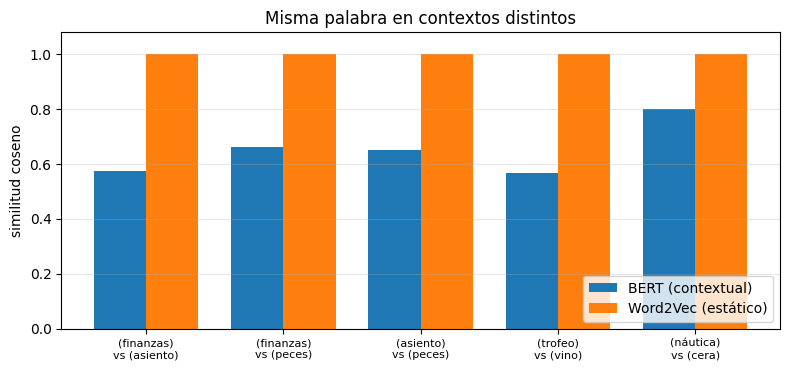

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.8))
x = np.arange(len(comp)); wdt = 0.38
ax.bar(x - wdt/2, comp['sim BERT'], wdt, label='BERT (contextual)')
ax.bar(x + wdt/2, comp['sim Word2Vec'], wdt, label='Word2Vec (estático)')
ax.set_xticks(x, [f"{a.split(' ')[1]}\nvs {b.split(' ')[1]}" for a, b in zip(comp['contexto 1'], comp['contexto 2'])], fontsize=8)
ax.set_ylabel('similitud coseno'); ax.set_ylim(0, 1.08); ax.legend(loc='lower right'); ax.grid(axis='y', alpha=.3)
ax.set_title('Misma palabra en contextos distintos')
plt.tight_layout(); plt.savefig('bert_vs_word2vec.png', dpi=120); plt.show()

## Task 3.2 c – Visualización PCA (2D) de los embeddings de BERT

PCA proyecta los vectores centrados $\tilde{\mathbf x}=\mathbf x-\boldsymbol\mu$ sobre los 2 vectores propios de mayor valor propio de la covarianza $\Sigma=\frac1n\tilde X^\top\tilde X$: $\mathbf z = W_2^\top\tilde{\mathbf x}$. Cada punto es una instancia de la palabra en su contexto; color = significado, marcador = palabra.

Varianza explicada: [0.35  0.235] | total = 0.586


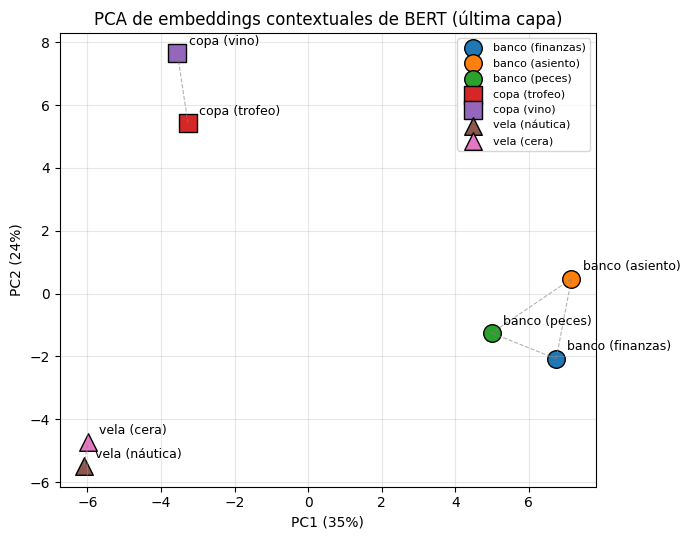

In [8]:
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(E)
print('Varianza explicada:', pca.explained_variance_ratio_.round(3), '| total =', pca.explained_variance_ratio_.sum().round(3))

markers = {'banco': 'o', 'copa': 's', 'vela': '^'}
colors = plt.cm.tab10(np.arange(len(DATA)))
fig, ax = plt.subplots(figsize=(7, 5.5))
for (sent, word, sense), z, c in zip(DATA, Z, colors):
    ax.scatter(*z, s=160, color=c, marker=markers[word], edgecolor='k', label=sense)
    ax.annotate(sense, z, xytext=(8, 6), textcoords='offset points', fontsize=9)
# Unir instancias de la misma palabra para ver la distancia entre sus significados
for word in markers:
    pts = Z[[i for i, d in enumerate(DATA) if d[1] == word]]
    for a, b in itertools.combinations(pts, 2):
        ax.plot(*zip(a, b), ls='--', lw=.8, color='gray', alpha=.6)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%})'); ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%})')
ax.set_title('PCA de embeddings contextuales de BERT (última capa)')
ax.legend(fontsize=8, loc='best'); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig('bert_pca.png', dpi=120); plt.show()

In [9]:
# Para contraste: los mismos 7 puntos con Word2Vec colapsan en solo 3 ubicaciones (una por palabra)
print('Puntos distintos en Word2Vec:', len({W[i].tobytes() for i in range(len(DATA))}), 'de', len(DATA))
print('Puntos distintos en BERT:    ', len({E[i].tobytes() for i in range(len(DATA))}), 'de', len(DATA))

Puntos distintos en Word2Vec: 3 de 7
Puntos distintos en BERT:     7 de 7


## Análisis

### 3.1 – Extracción
Las tres palabras objetivo (`banco`, `copa`, `vela`) existen como **un solo token** en el vocabulario WordPiece de mBERT, así que cada embedding es directamente $h_i^{(12)}\in\mathbb{R}^{768}$ de esa posición (el promedio de sub-tokens del código no tuvo que actuar). Se descartó el `[CLS]`, que resume la oración completa y no la palabra.

### 3.2 a – Similitudes BERT

| Palabra | Contexto 1 | Contexto 2 | sim BERT |
|---|---|---|---|
| banco | finanzas | asiento | 0.575 |
| banco | finanzas | peces | 0.660 |
| banco | asiento | peces | 0.650 |
| copa | trofeo | vino | 0.567 |
| vela | náutica | cera | 0.800 |

La misma palabra en contextos distintos tiene similitud media **0.65**, lejos de 1. Como referencia, dos palabras *distintas* tienen similitud media 0.39 (rango 0.32–0.49): BERT ubica a cada instancia en un punto intermedio, **todavía reconoce la forma de la palabra** (sim > 0.39) pero **su vector cambia según el significado** (sim < 1). El par más separado es `copa` trofeo vs. vino (0.567), y el más cercano `vela` náutica vs. cera (0.800); ambos sentidos de *vela* son objetos físicos y las oraciones comparten estructura (verbo transitivo + "vela" + "para" + infinitivo), lo que puede explicar que el contexto los diferencie menos.

### 3.2 b – Word2Vec vs. BERT

Con `word2vec-google-news-300` las cinco similitudes son exactamente **1.000**: el vector es $E[w]$ y no depende de la oración, así que comparar "banco (finanzas)" con "banco (peces)" es comparar un vector consigo mismo. La diferencia con BERT va de 0.20 (`vela`) a 0.43 (`copa`). Esto no depende del modelo elegido: **cualquier** embedding estático da 1.0 por construcción. Ese vector único mezcla todos los sentidos de la palabra según su frecuencia en el corpus. Además, Google News es un corpus en inglés y los vecinos de las palabras españolas (`banco` → *arriba, forza, deus…*) son poco informativos. Un Word2Vec en español daría mejores vecinos, pero las similitudes entre contextos seguirían siendo 1.0.

### 3.2 c – PCA

- Con Word2Vec, los 7 casos caen en solo **3 puntos** distintos (uno por palabra); con BERT hay **7 puntos** distintos.
- PC1 + PC2 explican el 58.6 % de la varianza. La estructura dominante es la **identidad de la palabra**: los tres `banco` a la derecha, `copa` arriba a la izquierda y `vela` abajo a la izquierda.
- **Dentro** de cada grupo, los significados sí se separan: los tres `banco` forman un triángulo (finanzas, asiento y peces en vértices distintos) y las dos `copa` están a ~2.3 unidades sobre PC2. Las dos `vela` quedan muy juntas, igual que en su similitud alta (0.80).
- Conclusión: los contextos distintos de la misma palabra **sí se separan**, pero en la última capa de mBERT esa separación es menor que la distancia entre palabras distintas. El embedding contextual = "identidad léxica" + "desplazamiento por contexto". Con 7 puntos en 768 dimensiones, la proyección 2D es solo indicativa; la tabla de similitudes es la evidencia cuantitativa principal.

### Prompt utilizado (Task 3)

> "Lee el proyecto y termina la task 3"; a partir de ahí, el asistente generó el código para cargar `bert-base-multilingual-cased`, ubicar la palabra objetivo con `offset_mapping`, calcular las similitudes coseno, compararlas con `word2vec-google-news-300` de gensim y visualizar con PCA.

**Por qué funcionó:** el enunciado del laboratorio ya definía las oraciones, las palabras, el modelo y las métricas exactas. Así, el resultado se pudo verificar directamente (dimensión 768 con `assert`, palabras presentes en el vocabulario de Word2Vec, similitudes estáticas = 1.0).
